# Running FORCE Level 2 and Download results

Desc: TODO

**Prerequisites**

1. openEO account on CDSE with credits

**Steps**

1. Connect to OpenEO backend
2. Make a query to the CDSE STAC catalog to determine input products
3. Run the FORCE l2ps on CDSE using OpenEO and the FORCE EO Application Package
4. Access and visualize the results

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import openeo
import contextily
import shapely
import pystac
import matplotlib.pyplot as plt
import rioxarray

import force_example_utils as utils

### Area of Interest

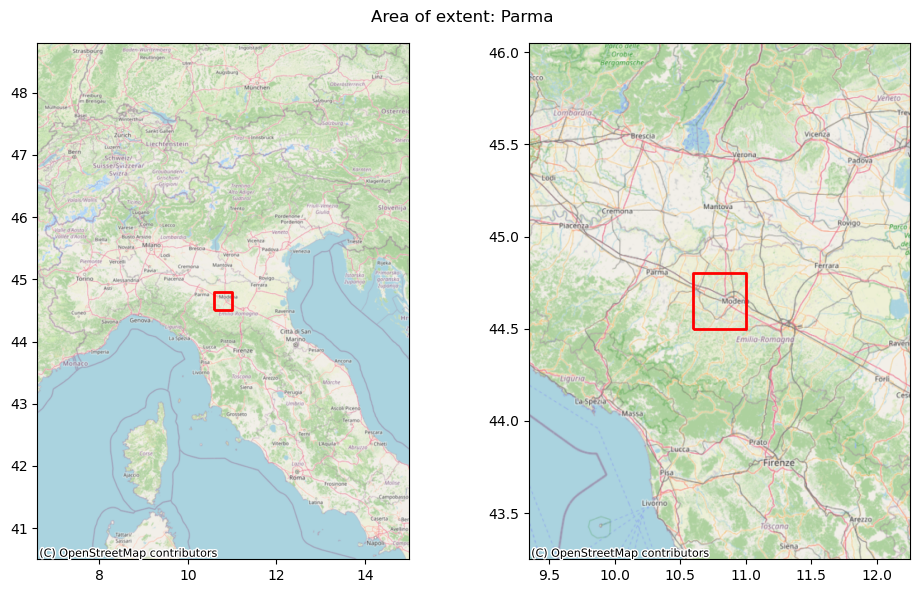

In [3]:
w,s,e,n = 10.6, 44.5, 11.0, 44.8
spatial_extent = { "west": w, "south": s, "east": e, "north": n}
aoi_name = "Parma"
temporal_extent=["2026-04-06", "2026-04-09"]

utils.plot_area_of_interest(
    w=w,
    s=s,
    e=e,
    n=n,
    large_context=4,
    figsize=(10, 6),
    title=f"Area of extent: {aoi_name}"
)

### Connect to the OpenEO backend

In [4]:
backend_url = "openeo-staging.dataspace.copernicus.eu"
connection = openeo.connect(backend_url).authenticate_oidc()

Authenticated using refresh token.


### Query the CDSE STAC catalog

In [5]:
L1C_COLLECTION_URL = "https://stac.dataspace.copernicus.eu/v1/collections/sentinel-2-l1c"

query_pg = connection.datacube_from_process(
    "query_stac",
    url=L1C_COLLECTION_URL,
    temporal_extent=temporal_extent,
    spatial_extent=spatial_extent
)

### Inspect query results

This step is optional. It helps to visualize what the query returns:

In [6]:
res = connection.execute(query_pg)

In [7]:
print(f"The query returned {len(res['features'])} product(s)\n")
item = pystac.Item.from_dict(res["features"][0])
item

The query returned 1 product(s)



<Item id=S2C_MSIL1C_20260407T101021_N0512_R022_T32TPQ_20260407T142059>

### Running FORCE level 2 (l2ps)

We need to tell FORCE on which products to run. The processor will automatically download the necessary files.
As usual in openEO, we can chain processes. In this case, we can connect the query directly to FORCE level2, without evaluating it.
Note that we use the openEO process graph `query_pg` and not the query results as a parameter.

#### Note:

**You will be able to use a dedicated process `force_level2` instead of `run_cwl_to_stac` which will make it unnecessary to explicitly pass the CWL document in the future.
Until this process is available on the CDSE openEO backend, `run_cwl_to_stac` can be used.**

#### openEO

You can track the progress of your job by logging into the openEO web interface 

Alternatively, in a separate Python shell / notebook, you can run the following snippet to get access to the logs as a Python list.
You can find out the job id from the next cell below.

Please be aware that the output from CWL jobs is not optimized for openEO logs, so the logs may look quite messy and fragmented. 
However, they can be a valuable source of information to debug issues.

```Python
connection = ... # connect to the same backend
l2_job = connection.job(<job-id>)
l2_logs = l2_job.logs()
print("\n".join(l2_logs[:20]))
```

In [8]:
cwl_text = Path("force-level2.cwl").read_text()
context = dict(
    stac_document=query_pg,
)

stac_resource = openeo.rest.stac_resource.StacResource(
    graph=openeo.internal.graph_building.PGNode(
        process_id="run_cwl_to_stac",
        arguments={
            "cwl_url": cwl_text,
            "context": context,
        }
    ),
    connection=connection,
)
l2_job = stac_resource.create_job(title=f"FORCE level 2 - {aoi_name}")
print(f"Job id: '{l2_job.job_id}'")
l2_job.start_and_wait()

Job id: 'j-26041715204246f3b73834d3ed470240'
0:00:00 Job 'j-26041715204246f3b73834d3ed470240': send 'start'
0:00:14 Job 'j-26041715204246f3b73834d3ed470240': created (progress 0%)
0:00:19 Job 'j-26041715204246f3b73834d3ed470240': created (progress 0%)
0:00:26 Job 'j-26041715204246f3b73834d3ed470240': created (progress 0%)
0:00:34 Job 'j-26041715204246f3b73834d3ed470240': running (progress 4.9%)
0:00:44 Job 'j-26041715204246f3b73834d3ed470240': running (progress 6.4%)
0:00:56 Job 'j-26041715204246f3b73834d3ed470240': running (progress 8.2%)
0:01:12 Job 'j-26041715204246f3b73834d3ed470240': running (progress 10.3%)
0:01:31 Job 'j-26041715204246f3b73834d3ed470240': running (progress 12.8%)
0:01:55 Job 'j-26041715204246f3b73834d3ed470240': running (progress 15.8%)
0:02:25 Job 'j-26041715204246f3b73834d3ed470240': running (progress 19.2%)
0:03:03 Job 'j-26041715204246f3b73834d3ed470240': running (progress 23.1%)
0:03:50 Job 'j-26041715204246f3b73834d3ed470240': running (progress 27.4%)
0:04

<BatchJob job_id='j-26041715204246f3b73834d3ed470240'>

## Download the results

Assets from the completed processing can be downloaded using openEO's `get_results` and `download_files` methods. The FORCE directory structure will automatically be respected.

In [9]:
l2_results = l2_job.get_results()
l2_results

<JobResults for job 'j-26041715204246f3b73834d3ed470240'>

In [10]:
assets_path = Path("force-level2-assets")
l2_results.download_files(assets_path)

[PosixPath('force-level2-assets/europe/X0031_Y0029/20260407_LEVEL2_SEN2C_BOA.tif'),
 PosixPath('force-level2-assets/europe/X0031_Y0029/20260407_LEVEL2_SEN2C_OVV.jpg'),
 PosixPath('force-level2-assets/europe/X0031_Y0029/20260407_LEVEL2_SEN2C_QAI.tif'),
 PosixPath('force-level2-assets/europe/X0031_Y0030/20260407_LEVEL2_SEN2C_BOA.tif'),
 PosixPath('force-level2-assets/europe/X0031_Y0030/20260407_LEVEL2_SEN2C_OVV.jpg'),
 PosixPath('force-level2-assets/europe/X0031_Y0030/20260407_LEVEL2_SEN2C_QAI.tif'),
 PosixPath('force-level2-assets/europe/X0032_Y0029/20260407_LEVEL2_SEN2C_BOA.tif'),
 PosixPath('force-level2-assets/europe/X0032_Y0029/20260407_LEVEL2_SEN2C_OVV.jpg'),
 PosixPath('force-level2-assets/europe/X0032_Y0029/20260407_LEVEL2_SEN2C_QAI.tif'),
 PosixPath('force-level2-assets/europe/X0032_Y0030/20260407_LEVEL2_SEN2C_BOA.tif'),
 PosixPath('force-level2-assets/europe/X0032_Y0030/20260407_LEVEL2_SEN2C_OVV.jpg'),
 PosixPath('force-level2-assets/europe/X0032_Y0030/20260407_LEVEL2_SEN2C_QAI

In [11]:
X, Y = "0031", "0029"
tiff_path = assets_path / "europe" / f"X{X}_Y{Y}" / "20260407_LEVEL2_SEN2C_BOA.tif"
ds = rioxarray.open_rasterio(tiff_path, masked=True)
#rgb_da = ds["band_data"].isel(band=slice(1, 4))
#rgb_da

rgb_da = ds.isel(band=slice(0,3))
rbg_da = rgb_da.transpose() # to order the data in R,G,B (not B, G, R, FORCE default)

In [12]:
rgb_da

<xarray.DataArray (band: 3, y: 7500, x: 7500)> Size: 675MB
[168750000 values with dtype=float32]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 60kB -8.556e+05 -8.555e+05 ... -7.056e+05
  * y            (y) float64 60kB -1.004e+06 -1.004e+06 ... -1.154e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('BLUE', 'GREEN', 'RED', 'REDEDGE1', 'REDEDGE2', 'REDEDGE...

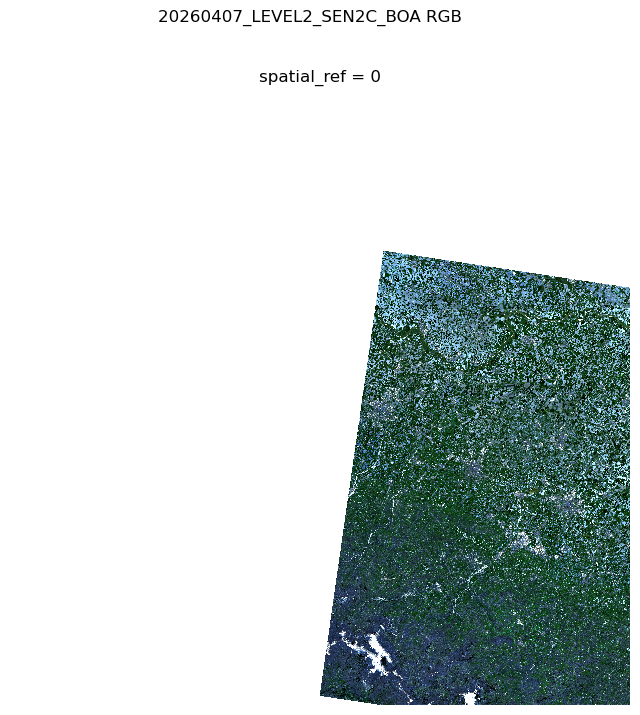

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb_da.plot.imshow(ax=ax, rgb="band", robust=True)
ax.axis("off")
fig.suptitle("20260407_LEVEL2_SEN2C_BOA RGB");